In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\avanindra Bose\OneDrive\Desktop\Real State Project\Cleaned Datasets\gurgaon_properties_cleaned_v2.csv")

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.head()

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,rof aalayas,sector 102,0.45,6000.0,750.0,Built Up area: 750 (69.68 sq.m.),1,1,2,...,NaN,750.0,NaN,0,0,0,0,0,1,0
1,house,huda sector-56 gurgaon,sector 56,3.60,24845.0,1449.0,Plot area 161(134.62 sq.m.),5,5,3+,...,NaN,1449.0,NaN,0,0,0,0,1,1,47
2,flat,parsvnath green ville,sector 48,2.50,12820.0,1950.0,Carpet area: 1950 (181.16 sq.m.),4,5,3,...,NaN,NaN,1950.00,0,0,0,0,1,0,49
3,flat,emaar gurgaon greens,sector 102,1.35,8181.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,...,1650.0,NaN,1022.58,0,1,0,0,0,1,119
4,flat,raheja sampada,sector 92,0.65,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,...,1370.0,NaN,NaN,0,0,0,0,0,1,49


In [8]:
df.shape

(3675, 23)

In [9]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_square_feet',
       'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum',
       'facing', 'agePossession', 'super_built_up_area', 'built_up_area',
       'carpet_area', 'study room', 'servant room', 'store room', 'pooja room',
       'others', 'furnishing_type', 'luxury_score'],
      dtype='object')

# Price

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\2797181776.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

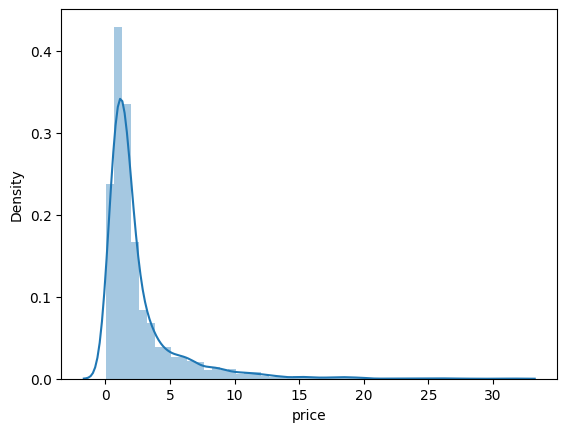

In [10]:
# outliers on the basis of price column
sns.distplot(df['price'])

<Axes: xlabel='price'>

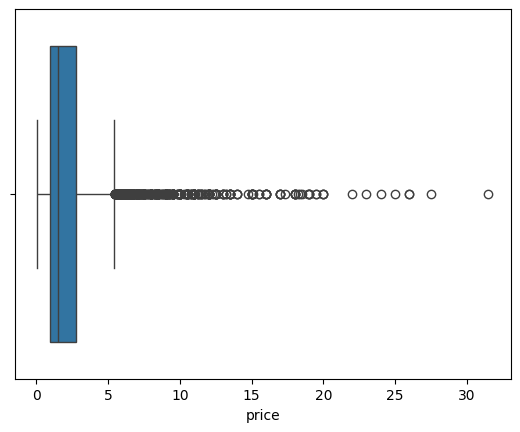

In [11]:

sns.boxplot(x=df['price'])

In [12]:
# Defining Inter Quaritle Range
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [13]:
print(lower_bound,upper_bound)

-1.7500000000000002 5.45


In [16]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

In [17]:
outliers.shape

(425, 23)

In [19]:
outliers['price'].describe()

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64

In [20]:
outliers.sort_values('price',ascending=False).head(20)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3111,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,...,NaN,9000.0,NaN,1,1,1,1,0,2,74
1752,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,...,NaN,11286.0,NaN,1,1,0,1,1,0,42
2262,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,...,NaN,400.0,350.0,1,1,1,1,0,0,72
222,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,...,NaN,4545.0,NaN,1,1,0,1,1,0,138
282,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,...,NaN,1000.0,NaN,1,1,1,1,0,1,0
1930,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,...,NaN,400.0,NaN,1,1,0,1,0,0,122
3253,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,...,NaN,9000.0,NaN,1,1,1,1,0,0,145
1819,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,...,NaN,1000.0,NaN,0,1,0,0,0,1,54
1416,house,dlf city plots,sector 26,20.00,44265.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,...,NaN,4518.0,NaN,1,1,1,1,0,0,153
1264,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,...,NaN,500.0,NaN,0,1,0,0,0,0,31


In [22]:
outliers[outliers['price'] == outliers['price'].max()]

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3111,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.5,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,...,NaN,9000.0,NaN,1,1,1,1,0,2,74


# On the basis of price col we can say that there are some genuine outliers but there are some data erros as well

# Price per square feet

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\3729580932.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_square_feet'])


<Axes: xlabel='price_per_square_feet', ylabel='Density'>

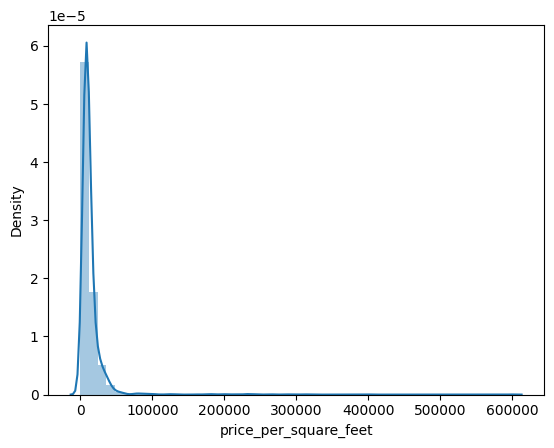

In [23]:
sns.distplot(df['price_per_square_feet'])

<Axes: xlabel='price_per_square_feet'>

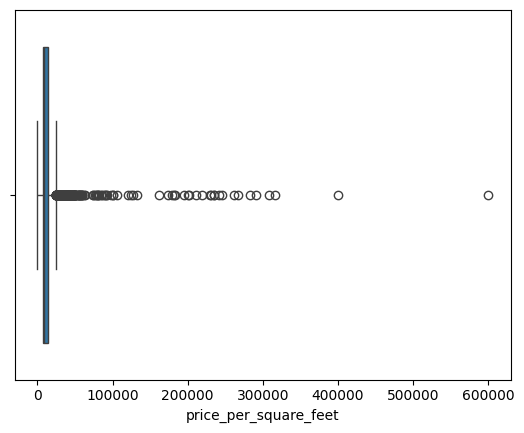

In [25]:
sns.boxplot(x=df['price_per_square_feet'])

In [27]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_square_feet'].quantile(0.25)
Q3 = df['price_per_square_feet'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_square_feet'] < lower_bound) | (df['price_per_square_feet'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_square_feet'].describe()

num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_square_feet, dtype: float64)

In [30]:
outliers[outliers['area'] < 1000]

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
116,house,vipul tatvam villa,sector 48,7.25,201388.0,360.0,Plot area 360(33.45 sq.m.),4,4,3,...,NaN,360.0,NaN,1,1,1,1,0,0,103
271,house,independent,sector 24,10.00,229885.0,435.0,Carpet area: 435 (40.41 sq.m.),8,10,3+,...,NaN,NaN,435.0,0,0,0,0,0,1,0
465,house,dlf the grove,sector 54,5.70,211111.0,270.0,Built Up area: 270 (25.08 sq.m.),4,4,0,...,NaN,270.0,NaN,0,0,0,0,0,1,46
477,house,uppal southend,sector 49,6.75,290948.0,232.0,Plot area 232(21.55 sq.m.),12,12,3+,...,NaN,232.0,NaN,1,1,0,1,1,0,49
696,house,independent,sector 13,9.00,100000.0,900.0,Plot area 900(83.61 sq.m.),10,5,3+,...,NaN,900.0,NaN,0,0,0,0,0,1,0
913,house,unitech uniworld resorts,sector 33,10.00,181818.0,550.0,Plot area 550(51.1 sq.m.),5,6,3,...,NaN,550.0,NaN,1,1,0,0,0,1,26
1486,house,unitech nirvana birch court,sector 50,7.10,283333.0,251.0,Plot area 240(22.3 sq.m.),3,3,3,...,NaN,240.0,NaN,0,1,0,0,0,1,49
1882,house,dlf city plots phase 2,sector 25,10.50,261194.0,402.0,Plot area 402(37.35 sq.m.),4,4,2,...,NaN,402.0,NaN,0,1,0,1,0,0,91
1930,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,...,NaN,400.0,NaN,1,1,0,1,0,0,122
1962,house,unitech deerwood chase,sector 50,8.45,235376.0,359.0,Plot area 359(33.35 sq.m.),3,3,2,...,NaN,359.0,NaN,1,1,0,0,0,0,102


I figured out that , we have around price_per_square_feet which are less than 1000 -> Unit Conversion has to be revisited

In [31]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [32]:
outliers_sqft['price_per_square_feet'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\946124031.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_square_feet'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [35]:
outliers_sqft['price_per_square_feet'].describe()

count      354.000000
mean     29357.906780
std      12403.077309
min       2723.000000
25%      25562.000000
50%      29870.500000
75%      35549.500000
max      82540.000000
Name: price_per_square_feet, dtype: float64

In [36]:
df.update(outliers_sqft)

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\3729580932.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_square_feet'])


<Axes: xlabel='price_per_square_feet', ylabel='Density'>

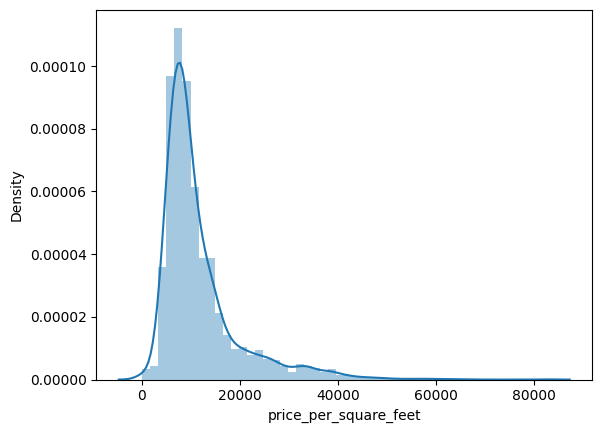

In [38]:
sns.distplot(df['price_per_square_feet'])

<Axes: xlabel='price_per_square_feet'>

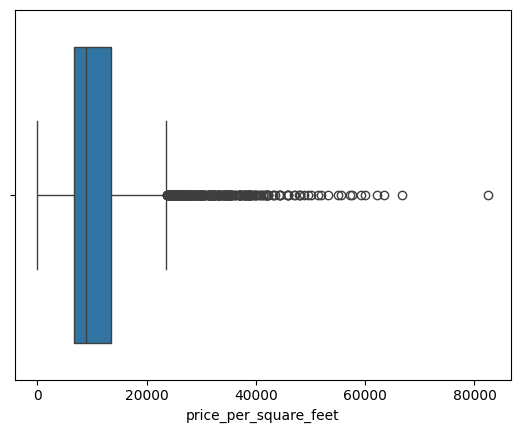

In [39]:
sns.boxplot(x=df['price_per_square_feet'])

In [41]:
df[df['price_per_square_feet']>50000]

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
222,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,...,NaN,4545.0,NaN,1,1,0,1,1,0,138
266,house,independent,sector 26,14.75,51864.0,2844.0,Plot area 316(264.22 sq.m.),16,20,3+,...,NaN,2844.0,NaN,1,1,1,1,0,0,153
278,house,emaar the palm springs,sector 54,14.00,62222.0,2250.0,Plot area 250(209.03 sq.m.),4,5,3+,...,NaN,2250.0,NaN,1,1,0,0,0,0,160
341,house,project housing board colony,sector 31,8.00,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,...,NaN,140.0,NaN,0,0,0,0,0,1,0
450,house,cloudnine cottages,sohna road road,5.50,55000.0,1000.0,Plot area 1000(92.9 sq.m.),3,3,0,...,NaN,1000.0,NaN,0,0,0,0,0,1,0
610,house,malibu towne,sector 47,8.50,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,...,NaN,1600.0,NaN,0,0,0,0,0,0,99
892,house,emaar mgf marbella,sector 66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,...,NaN,3240.0,NaN,1,1,0,1,0,2,75
1930,house,emaar the palm springs,sector 54,24.00,66667.0,3600.0,Plot area 400(37.16 sq.m.),5,5,2,...,NaN,400.0,NaN,1,1,0,1,0,0,122
2030,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,...,NaN,325.0,300.0,1,1,1,1,0,0,72
2262,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,...,NaN,400.0,350.0,1,1,1,1,0,0,72


In [43]:
df = df[df['price_per_square_feet'] <= 50000]

<Axes: xlabel='price_per_square_feet'>

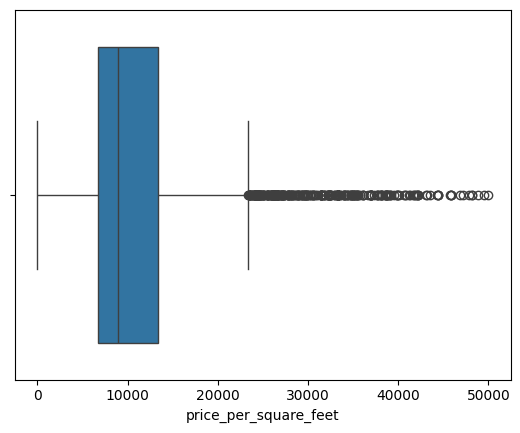

In [44]:
sns.boxplot(x=df['price_per_square_feet'])

# Area

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

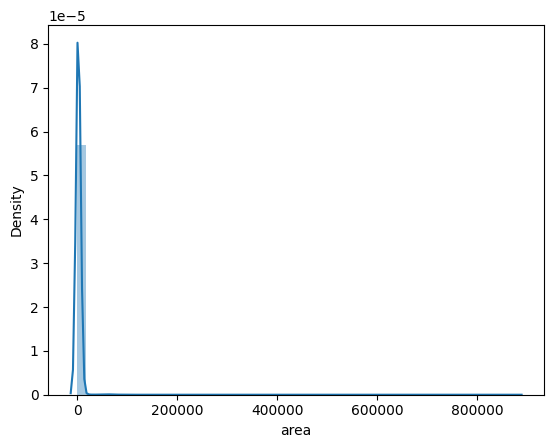

In [45]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

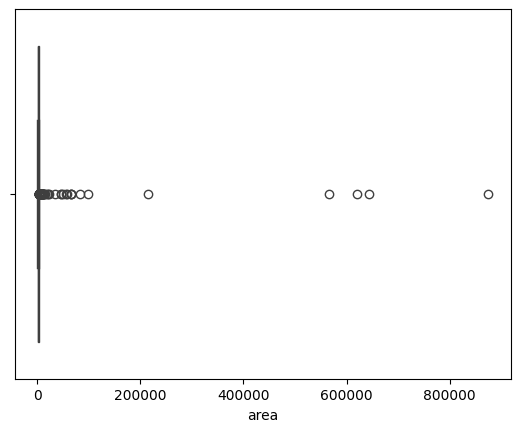

In [46]:
sns.boxplot(x=df['area'])

In [47]:
df['area'].describe()

count      3646.000000
mean       2948.202962
std       23211.359393
min         145.000000
25%        1262.000000
50%        1750.000000
75%        2350.000000
max      875000.000000
Name: area, dtype: float64

In [48]:
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
349,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,...,NaN,NaN,569243.0,0,0,0,0,0,1,76
462,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,...,NaN,NaN,514396.0,0,0,0,0,0,1,44
1174,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,...,NaN,737147.0,NaN,0,0,0,0,0,2,44
1228,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,...,NaN,NaN,607936.0,1,0,0,0,1,1,65
3161,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,...,NaN,2.0,NaN,1,1,0,1,1,0,0


In [49]:
df = df[df['area'] < 100000]

Choosing Area < 1,00,000 Square Feet , because the area > 10000 are purely outliers.

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

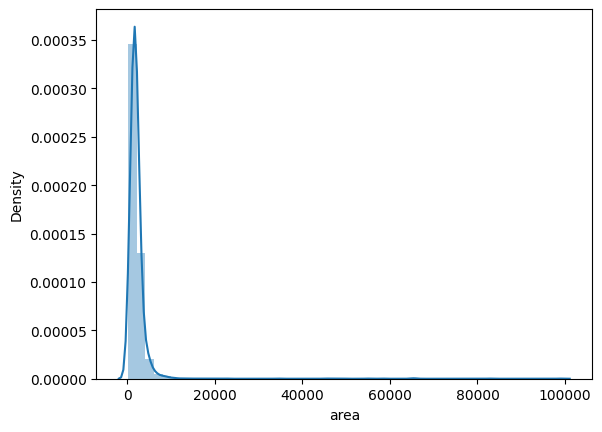

In [50]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

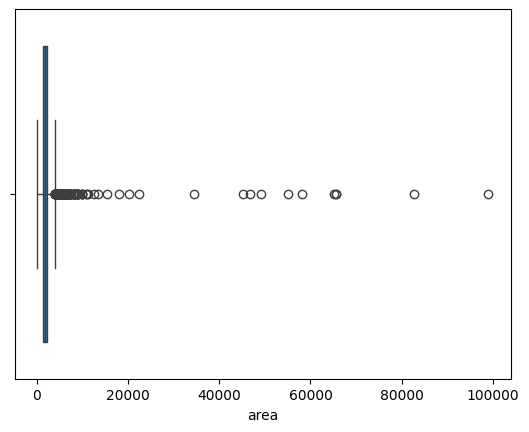

In [51]:
sns.boxplot(x= df['area'])

In [ ]:
df[df['area'] > 10000].sort_values('area',ascending=False)

# 2647 , 2709 , 2765 , 1714 , 3155 , 1709 , 3657 , 2658


,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2647,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,...,NaN,NaN,11000.00,0,1,1,1,0,0,60
3771,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,...,NaN,115.0,NaN,0,0,0,0,1,1,7
2709,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,...,NaN,NaN,64529.00,1,0,0,0,0,1,15
3263,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,...,NaN,NaN,64412.00,0,0,0,0,0,1,51
1393,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,...,NaN,NaN,7250.00,0,0,0,0,0,1,0
2765,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,NaN,NaN,58141.00,0,0,0,0,0,1,15
1714,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,...,NaN,NaN,54917.00,0,0,0,0,0,1,37
3155,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,...,NaN,NaN,48811.00,1,0,0,0,0,1,37
3224,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,...,NaN,5800.0,5200.00,0,1,1,0,0,0,109
1709,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,...,NaN,NaN,45966.00,0,0,0,0,1,1,33


In [53]:
df.drop(index=[2647 , 2709 ,3263, 2765 , 1714 , 3155 , 1709 , 3657 , 2658], inplace=True)

In [54]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3771,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,...,NaN,115.0,NaN,0,0,0,0,1,1,7
1393,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,...,NaN,NaN,7250.00,0,0,0,0,0,1,0
3224,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,...,NaN,5800.0,5200.00,0,1,1,0,0,0,109
3018,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,...,NaN,2660.0,2500.00,0,1,0,0,0,0,61
2816,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,...,NaN,2850.0,2250.00,1,1,0,1,1,0,123
3187,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,...,NaN,NaN,18122.00,1,0,0,1,1,0,44
1496,house,unitech aspen greens,sector 50,6.95,4490.0,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,...,NaN,2160.0,1720.00,0,1,0,0,0,1,160
2191,flat,godrej icon,sector 88a,1.75,1384.0,12645.0,Carpet area: 1175.11,3,3,3+,...,NaN,NaN,1175.11,0,0,0,0,0,1,55
1752,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,...,NaN,11286.0,NaN,1,1,0,1,1,0,42
831,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,...,NaN,NaN,11000.00,0,1,0,0,0,1,60


In [55]:
df.loc[3771,'area'] = 115*9
df.loc[1393,'area'] = 7250
df.loc[3224,'area'] = 5800
df.loc[3018,'area'] = 2660
df.loc[2816,'area'] = 2850
df.loc[3187,'area'] = 1812
df.loc[1496,'area'] = 2160
df.loc[2191,'area'] = 1175

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

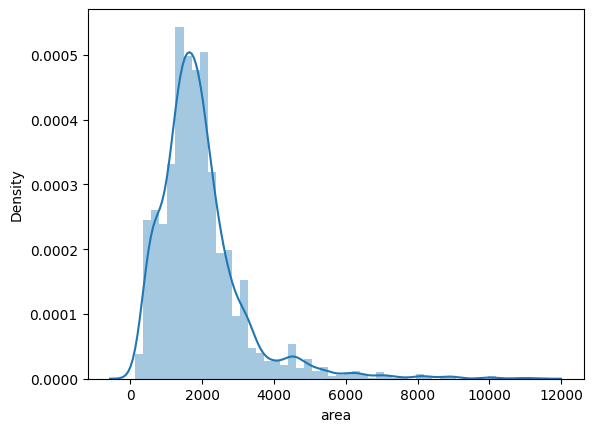

In [56]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

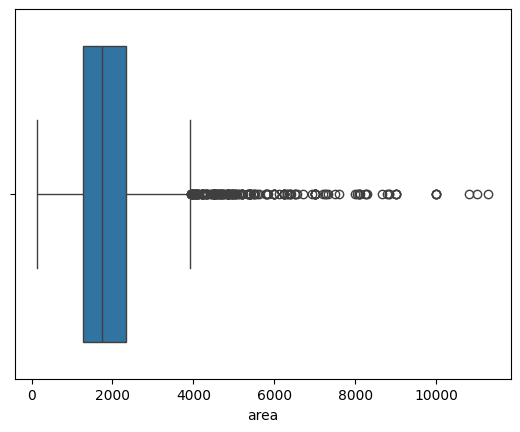

In [57]:
sns.boxplot(x=df['area'])

In [58]:
df['area'].describe()

count     3632.000000
mean      1950.563601
std       1215.811507
min        145.000000
25%       1260.750000
50%       1748.000000
75%       2326.000000
max      11286.000000
Name: area, dtype: float64

# BedRoom

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

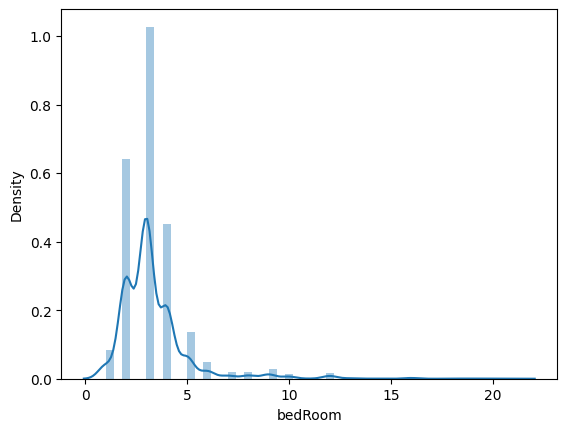

In [59]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

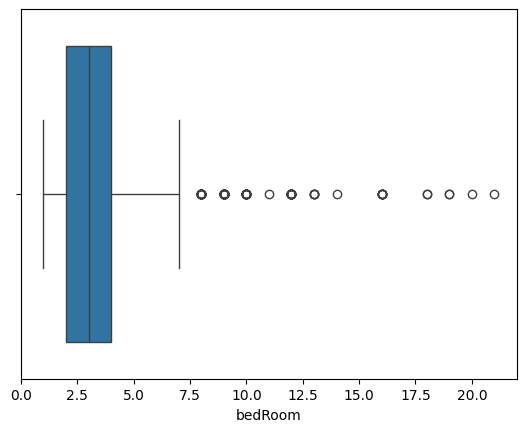

In [60]:
sns.boxplot(x=df['bedRoom'])

In [61]:
df['bedRoom'].describe()

count    3632.000000
mean        3.333976
std         1.830153
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [62]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
229,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,...,NaN,1161.0,NaN,0,1,0,0,0,2,49
2695,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,...,NaN,1152.0,NaN,0,1,0,0,0,2,22
1573,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,...,NaN,7500.0,NaN,1,0,1,0,0,1,68
3076,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,...,NaN,1622.0,NaN,1,1,1,1,0,1,74
441,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,...,NaN,1503.0,NaN,0,0,0,0,1,2,57
2803,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,...,NaN,1440.0,NaN,0,1,0,0,0,2,70
1264,house,luxury dlf city floors,sector 26,20.00,48888.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,...,NaN,500.0,NaN,0,1,0,0,0,0,31
1059,house,independent,sector 43,13.50,50000.0,2700.0,Plot area 300(250.84 sq.m.),16,16,3+,...,NaN,2700.0,NaN,1,1,0,1,1,1,41
1764,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16,18,2,...,NaN,2700.0,NaN,0,1,0,1,0,0,49
1416,house,dlf city plots,sector 26,20.00,44267.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,...,NaN,4518.0,NaN,1,1,1,1,0,0,153


Removing this because in such samll sqft area how can we have 10+ bedrooms , These are clearly outliers

In [63]:
df = df[df['bedRoom'] <= 10]

In [64]:
df.shape

(3587, 23)

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

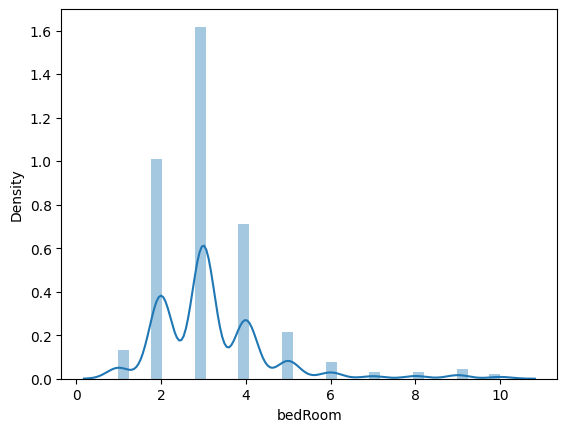

In [66]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

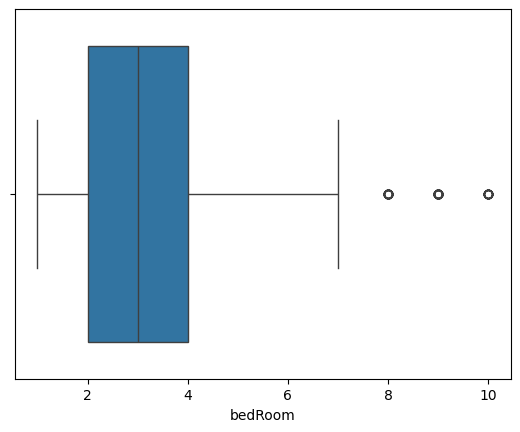

In [67]:
sns.boxplot(x=df['bedRoom'])

In [68]:
df['bedRoom'].describe()

count    3587.000000
mean        3.204070
std         1.394018
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

# Bath Room

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

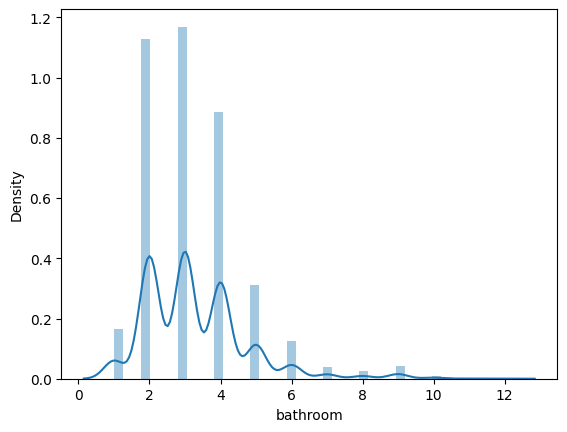

In [69]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

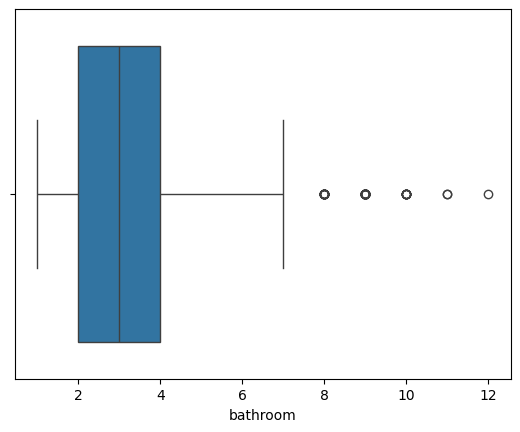

In [70]:
sns.boxplot(x=df['bathroom'])

In [71]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2079,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,...,NaN,6390.0,NaN,0,1,0,0,0,0,146
948,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,...,NaN,5000.0,NaN,1,1,0,1,1,0,39
1062,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,...,NaN,7000.0,NaN,0,0,0,1,0,0,38


# Super Built Up Area 

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

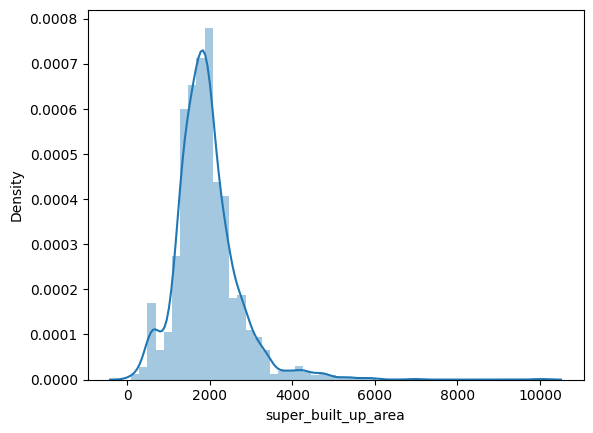

In [72]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

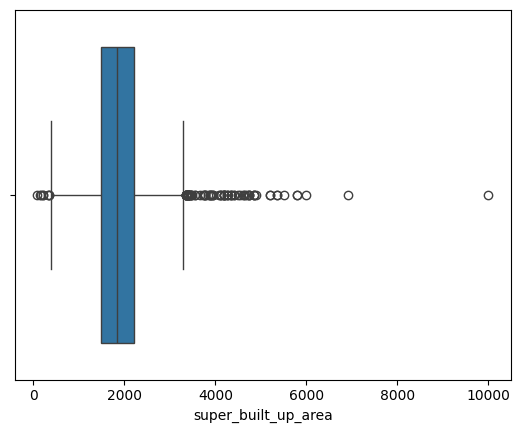

In [73]:
sns.boxplot(x=df['super_built_up_area'])

In [74]:
df['super_built_up_area'].describe()

count     1874.000000
mean      1925.624626
std        764.192336
min         89.000000
25%       1480.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [75]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1451,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,...,6926.0,NaN,NaN,0,1,0,0,0,0,140
2513,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,...,10000.0,NaN,NaN,0,1,0,1,1,1,49


# built up area

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

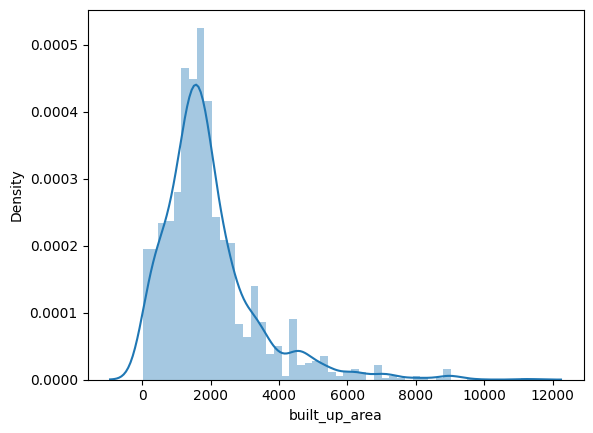

In [76]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

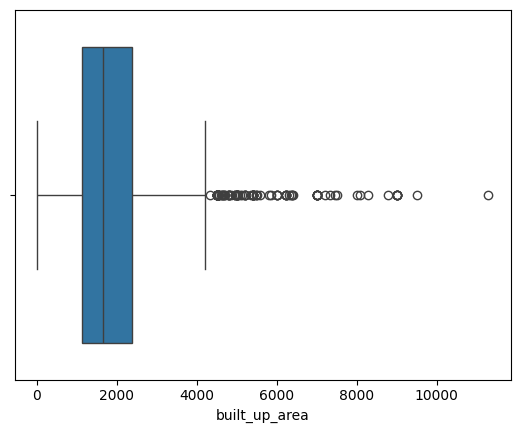

In [77]:
sns.boxplot(x=df['built_up_area'])

In [78]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1752,house,independent,sector 43,27.5,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,...,NaN,11286.0,NaN,1,1,0,1,1,0,42


# Carpet Area

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

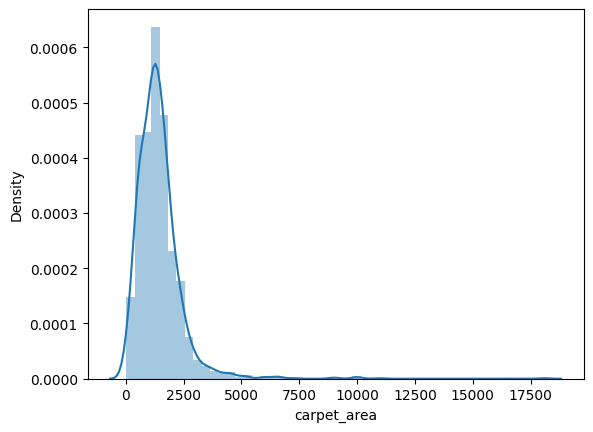

In [79]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

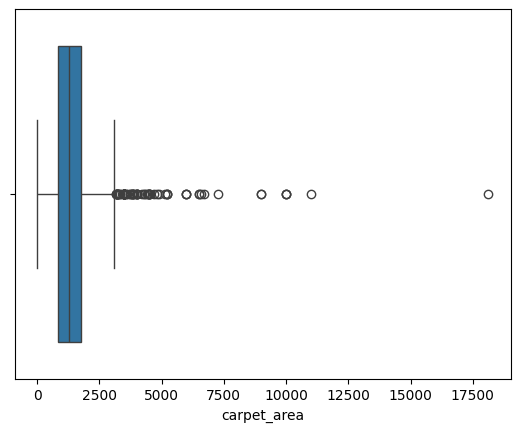

In [80]:
sns.boxplot(x=df['carpet_area'])

In [81]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
831,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,...,NaN,NaN,11000.0,0,1,0,0,0,1,60
3187,flat,godrej air,sector 85,2.5,1379.0,1812.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,...,NaN,NaN,18122.0,1,0,0,1,1,0,44


In [82]:
df.loc[3187,'carpet_area'] = 1812

In [83]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
831,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,...,NaN,NaN,11000.0,0,1,0,0,0,1,60


# Luxury Score

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

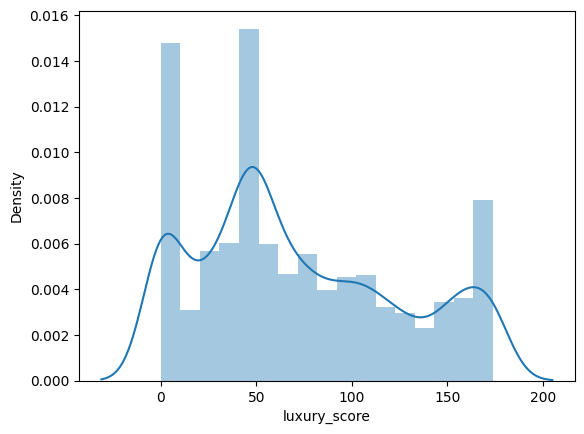

In [84]:
sns.distplot(df['luxury_score'])

<Axes: xlabel='luxury_score'>

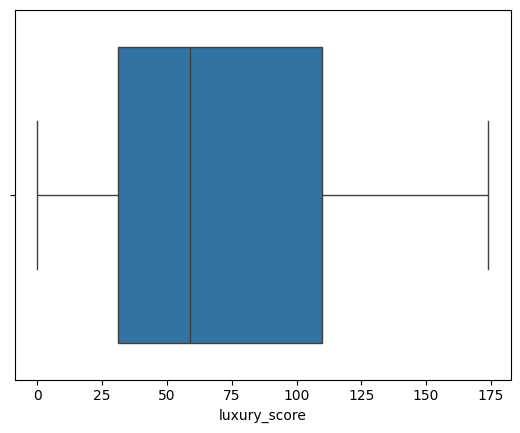

In [86]:
sns.boxplot(x = df['luxury_score'])

In [87]:
df.shape

(3587, 23)

In [88]:
df.head()

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,rof aalayas,sector 102,0.45,6000.0,750.0,Built Up area: 750 (69.68 sq.m.),1,1,2,...,NaN,750.0,NaN,0,0,0,0,0,1,0
1,house,huda sector-56 gurgaon,sector 56,3.60,24845.0,1449.0,Plot area 161(134.62 sq.m.),5,5,3+,...,NaN,1449.0,NaN,0,0,0,0,1,1,47
2,flat,parsvnath green ville,sector 48,2.50,12820.0,1950.0,Carpet area: 1950 (181.16 sq.m.),4,5,3,...,NaN,NaN,1950.00,0,0,0,0,1,0,49
3,flat,emaar gurgaon greens,sector 102,1.35,8181.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,...,1650.0,NaN,1022.58,0,1,0,0,0,1,119
4,flat,raheja sampada,sector 92,0.65,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,...,1370.0,NaN,NaN,0,0,0,0,0,1,49


In [91]:
x = df[df['price_per_square_feet'] < 20000]
(x['area']/x['bedRoom']).quantile(0.05)

np.float64(250.5)

In [93]:
df[df['area']/df['bedRoom'] < 250].sample(5)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
691,house,independent,sector 9,1.25,8735.0,1431.0,Plot area 159(132.94 sq.m.),10,6,3+,...,NaN,1431.0,NaN,0,0,0,0,0,1,0
2379,flat,gls arawali homes,sohna road,0.30,6243.0,481.0,Super Built up area 567(52.68 sq.m.)Carpet are...,2,2,2,...,567.0,NaN,480.53,0,0,0,0,0,2,120
1641,house,independent,sector 17,0.32,22068.0,145.0,Built Up area: 145 (13.47 sq.m.),2,2,0,...,NaN,145.0,NaN,0,0,0,0,0,1,0
136,house,independent,sector 4,1.10,6111.0,1800.0,Plot area 200(167.23 sq.m.),8,4,3+,...,NaN,1800.0,NaN,0,0,0,0,0,1,7
1100,house,independent,sector 2,1.15,19360.0,594.0,Plot area 66(55.18 sq.m.),3,3,2,...,NaN,594.0,NaN,0,0,0,0,0,0,32


2 Things we can say here : 

1. Either there is a mistake from the owner/agen while listing the property.
2. It must be a multi story house -> but still having a 9BHK in the area of 1400 is quiet difficult.

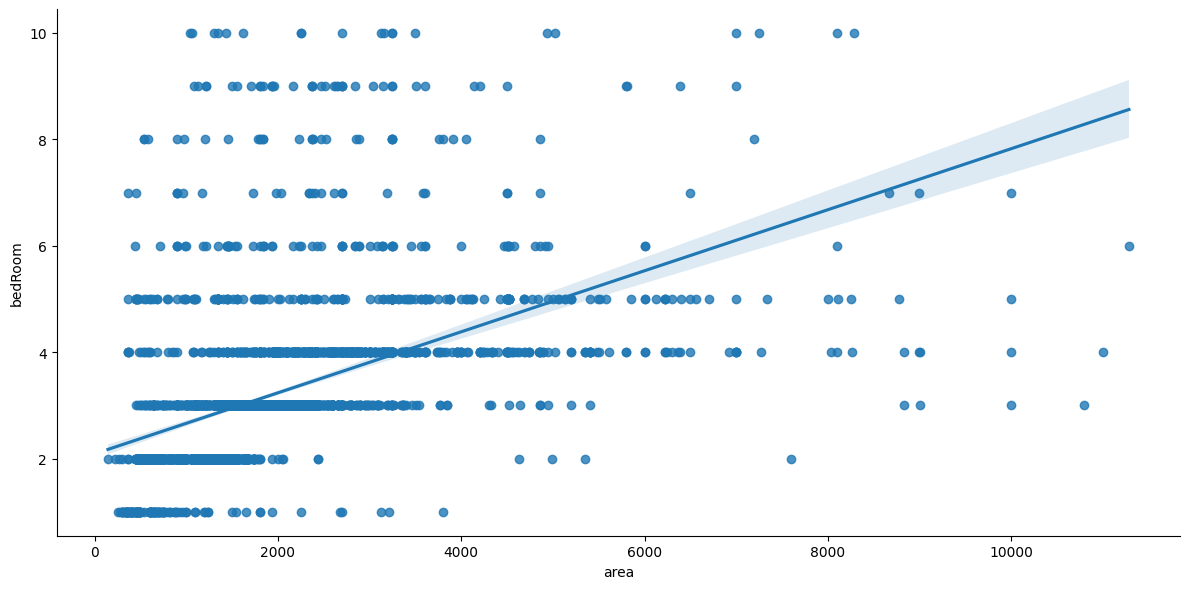

In [94]:
sns.lmplot(x='area',y='bedRoom',data=df,aspect=2,height=6)

In [95]:
df['area_room_ratio'] = df['area']/df['bedRoom']

In [97]:
df[df['area_room_ratio'] < 250].sort_values('area_room_ratio',ascending = True)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
3727,house,independent,sector 28,0.75,20833.0,360.0,Plot area 40(33.45 sq.m.),7,4,3+,...,360.0,NaN,0,0,0,0,0,1,7,51.428571
3701,house,ashok vihar phase iii extension,sector 3 phase 3 extension,0.40,8889.0,450.0,Plot area 50(41.81 sq.m.),7,4,3+,...,450.0,NaN,0,0,0,1,0,1,7,64.285714
2490,house,independent,sector 105,0.60,11102.0,540.0,Plot area 60(50.17 sq.m.),8,4,3,...,540.0,NaN,0,0,0,0,0,1,17,67.500000
2830,house,ansal,sector 43,1.85,34259.0,540.0,Plot area 60(5.57 sq.m.),8,8,3+,...,60.0,NaN,0,0,0,0,0,1,53,67.500000
3785,house,independent,sector 6,0.50,13889.0,360.0,Plot area 40(33.45 sq.m.),5,3,3,...,360.0,NaN,0,0,0,0,0,1,0,72.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,flat,pyramid urban homes 2,sector 86,0.41,8283.0,495.0,Carpet area: 501 (46.54 sq.m.),2,2,1,...,NaN,501.0,1,1,0,1,1,1,49,247.500000
916,flat,pyramid urban homes 2,sector 86,0.42,8483.0,495.0,Carpet area: 501 (46.54 sq.m.),2,2,1,...,NaN,501.0,1,1,0,1,1,1,84,247.500000
3112,flat,zara aavaas,sector 104,0.49,6577.0,745.0,Super Built up area 745(69.21 sq.m.)Carpet are...,3,2,2,...,NaN,645.0,0,0,0,0,0,1,74,248.333333
2240,flat,prime habitat,sector 99a,0.27,5432.0,497.0,Carpet area: 497 (46.17 sq.m.),2,2,1,...,NaN,497.0,0,0,0,0,0,1,7,248.500000


In [99]:
df = df[df['area_room_ratio'] >= 100]

In [103]:
outliers_df = df[(df['area_room_ratio'] < 250) & (df['bedRoom'] > 3)]

In [106]:
outliers_df['bedRoom'] = round(outliers_df['bedRoom']/outliers_df['floorNum'])

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_78648\3450078040.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_df['bedRoom'] = round(outliers_df['bedRoom']/outliers_df['floorNum'])


In [107]:
df.update(outliers_df)

In [108]:
df.head(2)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,rof aalayas,sector 102,0.45,6000.0,750.0,Built Up area: 750 (69.68 sq.m.),1,1,2,...,750.0,NaN,0,0,0,0,0,1,0,750.0
1,house,huda sector-56 gurgaon,sector 56,3.60,24845.0,1449.0,Plot area 161(134.62 sq.m.),5,5,3+,...,1449.0,NaN,0,0,0,0,1,1,47,289.8


In [110]:
df[(df['area_room_ratio'] < 250) & (df['bedRoom'] > 4)]

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
123,house,independent,sector 7,1.16,11717.0,990.0,Carpet area: 110 (91.97 sq.m.),5,4,2,...,NaN,110.0,0,0,0,0,0,1,0,198.000000
1095,house,shivpuri,sector 7,2.80,12444.0,2250.0,Plot area 2250(209.03 sq.m.),10,7,3,...,2250.0,NaN,1,1,0,1,1,0,0,225.000000
1122,house,independent,sector 3 phase 2,0.85,9444.0,900.0,Carpet area: 900 (83.61 sq.m.),5,3,3,...,NaN,900.0,0,0,0,0,0,1,0,180.000000
1402,house,independent,sector 12,2.50,13888.0,1800.0,Plot area 1800(167.23 sq.m.),9,5,2,...,1800.0,NaN,0,0,0,1,0,1,8,200.000000
1497,house,independent,sector 17,0.32,5664.0,565.0,Built Up area: 565 (52.49 sq.m.),5,1,0,...,565.0,NaN,0,0,0,0,0,1,0,113.000000
1756,house,independent,sector 2,0.98,9074.0,1080.0,Carpet area: 120 (100.34 sq.m.),9,4,3,...,NaN,120.0,0,0,0,0,0,1,0,120.000000
1807,house,independent,sector 12,0.65,6500.0,1000.0,Carpet area: 1000 (92.9 sq.m.),6,2,3,...,NaN,1000.0,0,0,0,0,0,1,0,166.666667
2298,house,independent,manesar,1.10,6172.0,1782.0,Plot area 1782(165.55 sq.m.),8,8,0,...,1782.0,NaN,0,0,0,0,0,1,0,222.750000
2429,house,independent,manesar,0.80,6666.0,1200.0,Plot area 1200(111.48 sq.m.),8,8,2,...,1200.0,NaN,0,0,0,0,0,1,0,150.000000
2851,house,independent,sector 11,3.50,15555.0,2250.0,Built Up area: 2250 (209.03 sq.m.),10,1,0,...,2250.0,NaN,0,0,0,0,0,1,0,225.000000


In [111]:
df.drop(index = [123,1095,1122,1402,1497,1756,1807,2298,2429,2851,2874,3130,3243] , inplace=True)

In [113]:
df.shape

(3554, 24)

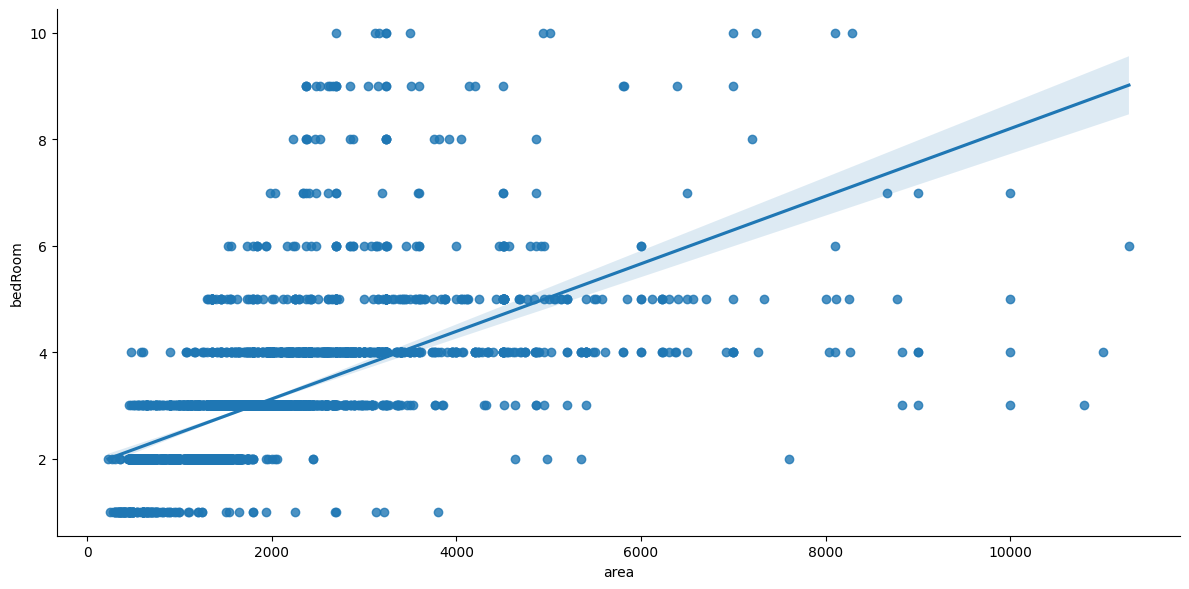

In [114]:
sns.lmplot(x='area',y='bedRoom',data=df,aspect=2,height=6)

In [121]:
df.to_csv('gurgaon_properties_outliers_treated.csv', index=False)